# CN3 - MODÈLE PROBABILISTE DE LA MARCHE ALÉATOIRE

Objectif : « *simuler la marche au hasard d'un grand nombre de particules à partir d'un centre et caractériser l'étalement spatial de cet ensemble de particules au cours du temps.* »

## A) Rappel théorique

Un modèle de marche aléatoire permet de simuler le déplacement erratique des particules à l'échelle microscopique ; ce qu’on appelle le mouvement brownien. On étudie une particule ou un ensemble de particules dans un milieu diffusant, qui se déplace au gré des chocs aléatoires. On suppose pous simplifier :
 - la diffusion s’effectue le long d’un seul axe (modèle unidimensionnel, ou 1D) ;
 - chaque particule effectue un saut de longueur fixe $\ell$ pendant une durée fixe $\tau$ (modèle discret) ;
 - chaque particule a la même probabilité d’aller à gauche ou à droite (modèle isotrope, ou non biaisé).


Nous avons montré en cours que la probabilité $P(x,t)$ que la particule soit à la position $x$ à l'instant $t$ vérifie l'équation de diffusion
$$
\boxed{\frac{\partial P}{\partial t} = D \frac{\partial^2 P}{\partial x^2}},
$$
où $D=\ell^2/2\tau$ est le coefficient de diffusion. Nous souhaitons observer les propriétés de la diffusion sur une simulation de marche aléatoire d’un grand nombre de particules. Dans toute la suite, nous poserons $\ell=1$ et $\tau=1$. 

## B) Marche aléatoire à une particule

>**Question 1**
>
> Nous définissons la fonction ```marche(Nstep)```  qui renvoie la liste `X` des positions successives après `Nstep` sauts. Compléter la ligne pointillée de façon à actualiser la nouvelle position $x$ de la particule après son saut aléatoire.

In [37]:
""" BIBLIOTHEQUES """
import numpy as np
import random as r

""" FONCTION """
def marche(Nstep):
    """
    Entrée : Nstep (int)
    Sortie : x (list[float])
    """
    X = np.zeros(Nstep)                      # position initiale
    for i in range(1,Nstep):                 # boucle sur les sauts
        X[i] = X[i-1] + r.choice([-1,+1])    # saut gauche ou droite
    return X                                 # retour liste positions

>**Question 2**
>
> Compléter le début du code suivant pour réaliser trois simulations indépendantes de la marche aléatoire. Compléter le code pour afficher les lois horaires x(t) de la particule pour chaque simulation et commenter.

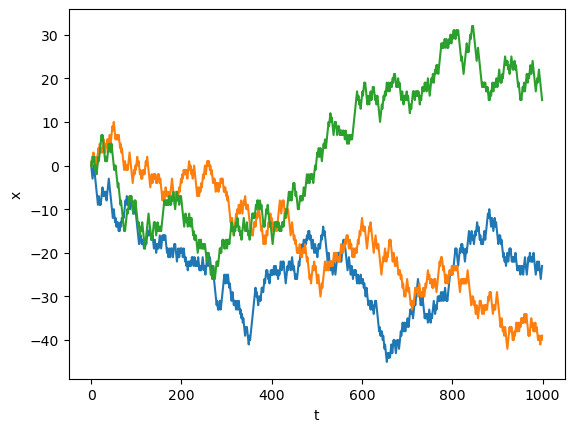

In [38]:
""" TROIS SIMULATIONS """
Nstep = 1000
X1 = marche(Nstep)
X2 = marche(Nstep)
X3 = marche(Nstep)

""" GRAPHIQUE """
import matplotlib.pyplot as plt

temps = range(Nstep) # liste des instants de saut

plt.figure()        # initialisation de la figure
plt.xlabel('t')     # étiquette axe abscisse
plt.ylabel('x')     # étiquette axe ordonnée
plt.plot(temps,X1)  # graphes
plt.plot(temps,X2)
plt.plot(temps,X3)
plt.show()          # affichage
plt.close()         # suppression affichage

## B) Marche aléatoire à grand nombre departicules

>**Question 3**
>
> On considère maintenant la diffusion d’un grand nombre `Npart` de particules indépendantes à partir de la position origine x=0. On souhaite définir une fonction similaire à `marche` pour simuler la marche aléatoire de ces N particules. Compléter le code suivant pour définir la fonction `marche_Nparticules(Nstep, Npart)`. Réaliser une simulation de 1000 sauts à 1000 particules.

In [39]:
""" FONCTION """
def marche_Nparticules(Nstep, Npart):
    """
    Entrée : Nstep (int), Npart (int)
    Sortie : X (array : Nstep x Npart)
    """
    X = np.zeros((Nstep,Npart))                       # position initiale des particules
    for i in range(1,Nstep):                          # boucle sur les sauts
        for j in range(Npart):                        # boucle sur les particules
            X[i,j] = X[i-1,j] + r.choice([-1,+1])     # saut gauche ou droite
    return X

""" SIMULATION """
Nstep = 500
Npart = 5000
X = marche_Nparticules(Nstep,Npart)

>**Question 4**
>
> On souhaite suivre la distribution spatiale de l’ensemble particules à différents instants pour observer la diffusion. On définit le code de la fonction `compte(X, i)` ci-dessous, qui prend en entrée le tableau des positions des particules `X` et l’instant `i`, et renvoie la liste du nombre `N[j]` de particules à la position `j`. Expliquer ce code avec précision. En particulier :
> - expliquer pourquoi il est pertinent d’initialiser `N` par une liste vide ;
> - déterminer l’ensemble des positions possibles à l’instant `i` ;
> - expliquer ce que renvoie la commande `sum(X[i,:] == j)`.

In [40]:
""" DISTRIBUTION """
def compte(X, i):
    """
    Entrée : i (int)
    Sortie : positions (list[int]), N (liste[int])
    """
    N = []                         # initialisation nombre de particules   
    x = range(-i,+i+1,2)           # positions possibles des particules
    for j in x:                    # boucle sur les positions
        N.append(sum(X[i,:] == j)) # comptage nombre N de particules
    return x, N                    # retour des positions et nombre de particules associées    

>**Question 5**
>
> Compléter le code suivant pour afficher la distribution spatiale des particules à quatre instants différents. Commenter les courbes obtenues. Le comportement observé est-il cohérent qualitativement avec un processus diffusif.

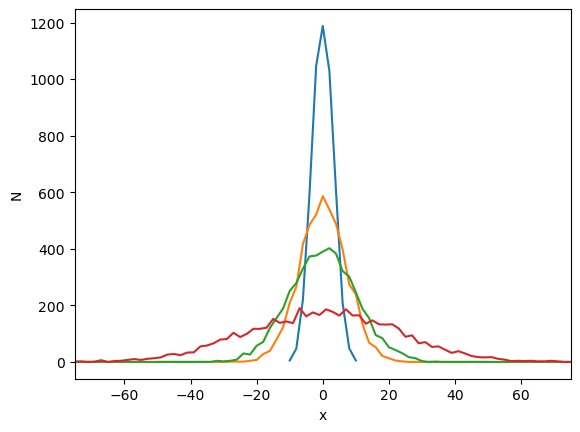

In [41]:
""" QUATRE INSTANTS """
x1, N1 = compte(X, 10)
x2, N2 = compte(X, 50)
x3, N3 = compte(X, 100)
x4, N4 = compte(X, 499)

""" GRAPHIQUE """
plt.figure()        # initialisation de la figure
plt.xlim(-75,75)    # échelle abscisse
plt.xlabel('x')     # étiquette axe abscisse
plt.ylabel('N')     # étiquette axe ordonnée
plt.plot(x1,N1)     # graphes
plt.plot(x2,N2)
plt.plot(x3,N3)
plt.plot(x4,N4)
plt.show()          # affichage
plt.close()         # suppression affichage

>**Question 6**
>
> On souhaite vérifier quantitativement les propriétés de la diffusion. En particulier, la loi d’échelle de la diffusion indique que l’étalement spatial $\delta$ de la distribution de particules vérifie $\delta \propto \sqrt{t}$. Nous associons ici $\delta$ à la demi-largeur à mi-hauteur de la distribution spatiale des particules. Compléter la fonction `demi_largeur(i)` puis afficher les fonctions $\delta(t)$ issus de la simulation et de la loi d’échelle $\delta \propto \sqrt{t}$. On pourra choisir le préfacteur adéquat pour que les données soient les plus proches possibles de la loi. Commenter, et effectuer d’autres simulations, avec le même nombres de particules, puis avec un nombre de particules différent.

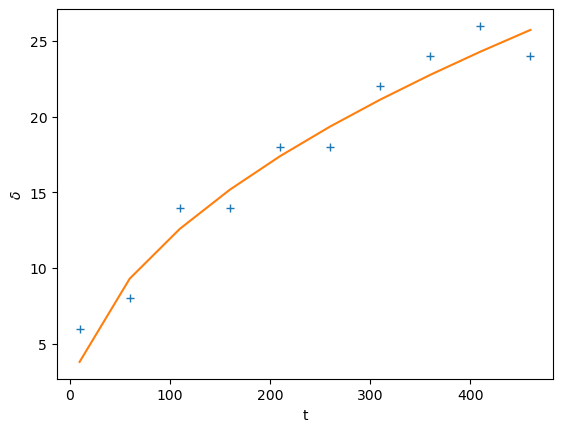

In [42]:
""" DISTANCE TYPIQUE """
def demi_largeur(i):
    xi, Ni = compte(X, i)  # positions et nombre de particules à l’instant i
    Nmax = max(Ni)         # nombre maximal de particules, au centre
    N = Nmax               # initialisation N
    jmax = Ni.index(Nmax)  # initialisation position au centre
    while N > Nmax/2:      # tant que mi-hauteur non atteinte
        jmax += 1          # incrémenter position
        N = Ni[jmax]       # chercher nombre de particules position suivante
    return xi[jmax]        # retour demi-largeur

""" AFFICHAGE """
temps = range(10,Nstep,50)
delta_simu = [demi_largeur(i) for i in temps]
delta_theo = [1.2*np.sqrt(i) for i in temps]
plt.figure()
plt.xlabel('t')
plt.ylabel(r'$\delta$')
plt.plot(temps,delta_simu,'+')
plt.plot(temps,delta_theo,'-')
plt.show()
plt.close()